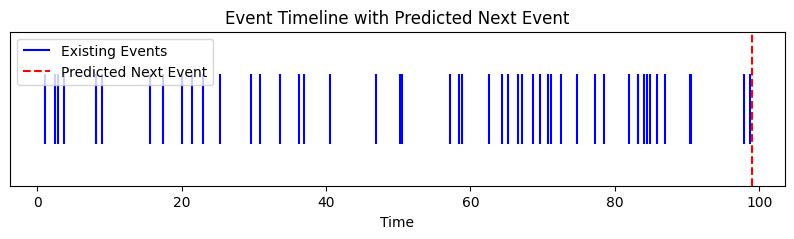

Predicted next event will occur at time: 98.97


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def generate_random_events(num_events, start_time=0, end_time=100):
    """
    Generate random events with timestamps between start_time and end_time.

    Parameters:
    - num_events: Number of events to generate.
    - start_time: The starting timestamp.
    - end_time: The ending timestamp.

    Returns:
    - events: A sorted numpy array of event timestamps.
    """
    events = np.sort(np.random.uniform(start_time, end_time, num_events))
    return events

def hawkes_next_event_prediction(events, mu, alpha, beta):
    """
    Predict the time of the next event using a simple Hawkes process.

    Parameters:
    - events: Array of event timestamps.
    - mu: Baseline intensity (background rate of events).
    - alpha: Excitation parameter (impact of past events on future events).
    - beta: Decay rate of the excitation over time.

    Returns:
    - next_event_time: Predicted timestamp of the next event.
    """
    current_time = events[-1]
    intensity = mu
    for event_time in events:
        intensity += alpha * np.exp(-beta * (current_time - event_time))
    
    # Time until next event is exponentially distributed with rate equal to the current intensity
    time_until_next_event = np.random.exponential(1 / intensity)
    next_event_time = current_time + time_until_next_event
    return next_event_time

# Parameters
num_events = 50
mu = 0.5    # Baseline intensity
alpha = 0.8 # Excitation factor
beta = 1.0  # Decay rate

# Generate random events
events = generate_random_events(num_events)

# Predict the next event time
next_event_time = hawkes_next_event_prediction(events, mu, alpha, beta)

# Plotting the events and the predicted next event
plt.figure(figsize=(10, 2))
plt.eventplot(events, orientation='horizontal', colors='blue', label='Existing Events')
plt.axvline(x=next_event_time, color='red', linestyle='--', label='Predicted Next Event')
plt.xlabel('Time')
plt.yticks([])
plt.title('Event Timeline with Predicted Next Event')
plt.legend()
plt.show()

print(f"Predicted next event will occur at time: {next_event_time:.2f}")


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Feedforward Neural Network
class FeedforwardNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Example usage
input_size = 10   # Number of input features
hidden_size = 5   # Number of neurons in the hidden layer
output_size = 2   # Number of output classes

# Create an instance of the network
model = FeedforwardNN(input_size, hidden_size, output_size)

# Example input tensor with batch size of 1
input_tensor = torch.randn(1, input_size)

# Forward pass
output = model(input_tensor)
print(output)


tensor([[0.3006, 0.0365]], grad_fn=<AddmmBackward0>)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Recurrent Neural Network
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), hidden_size)  # Initial hidden state
        out, hn = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])  # Use the last output
        return out

# Example usage
input_size = 3    # Number of features in the input
hidden_size = 5   # Number of features in the hidden state
output_size = 2   # Number of output classes
sequence_length = 7  # Length of the input sequence

# Create an instance of the network
model = SimpleRNN(input_size, hidden_size, output_size)

# Example input tensor with batch size of 1
input_tensor = torch.randn(1, sequence_length, input_size)

# Forward pass
output = model(input_tensor)
print(output)


tensor([[-0.1225, -0.1604]], grad_fn=<AddmmBackward0>)
